In [35]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Upload Dataset

from google.colab import files
uploaded = files.upload()
df = pd.read_csv("feature-engineered-data.csv")
X = df.drop("Attrition", axis=1)
y = df["Attrition"]
print("Dataset shape:", df.shape)
print("Attrition distribution:\n", y.value_counts())

Saving feature-engineered-data.csv to feature-engineered-data (1).csv
Dataset shape: (1470, 51)
Attrition distribution:
 Attrition
0    1233
1     237
Name: count, dtype: int64


In [5]:
# Upload raw dataset for demographic analysis

uploaded2 = files.upload()  # uploading processed-data.csv (has original string columns)
df_raw = pd.read_csv("processed-data.csv")
print("\nRaw dataset shape:", df_raw.shape)

Saving processed-data.csv to processed-data.csv

Raw dataset shape: (1470, 31)


In [7]:
# Upload Models

uploaded3 = files.upload()
log_model = joblib.load("logistic-regression.pkl")
rf_model  = joblib.load("random-forest.pkl")
xgb_model = joblib.load("xgboost.pkl")
print("Models loaded")

Saving logistic-regression.pkl to logistic-regression.pkl
Saving xgboost.pkl to xgboost.pkl
Saving random-forest.pkl to random-forest (1).pkl
Models loaded


In [11]:
# ATTRITION CORE ANALYSIS
# For Dataset Page — Imbalance Core Section

attrition_counts = df_raw["Attrition"].value_counts()
attrition_rate   = (attrition_counts["Yes"] / len(df_raw) * 100).round(1)
stayed_rate      = (attrition_counts["No"]  / len(df_raw) * 100).round(1)

print(f"Total Employees : {len(df_raw)}")
print(f"Stayed          : {attrition_counts['No']}  ({stayed_rate}%)")
print(f"Left            : {attrition_counts['Yes']} ({attrition_rate}%)")
print(f"Imbalance Ratio : {stayed_rate}% / {attrition_rate}%")

Total Employees : 1470
Stayed          : 1233  (83.9%)
Left            : 237 (16.1%)
Imbalance Ratio : 83.9% / 16.1%


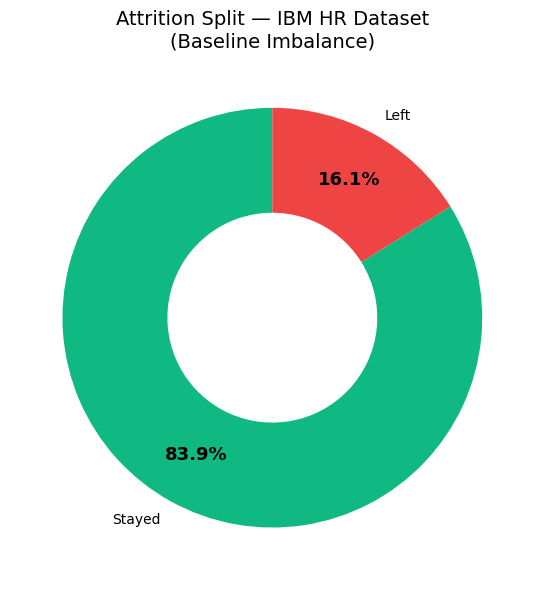

In [12]:
# Attrition donut chart

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#10b981", "#ef4444"]
wedges, texts, autotexts = ax.pie(
    [attrition_counts["No"], attrition_counts["Yes"]],
    labels=["Stayed", "Left"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5)
)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight("bold")
ax.set_title("Attrition Split — IBM HR Dataset\n(Baseline Imbalance)", fontsize=14)
plt.tight_layout()
plt.savefig("attrition_donut.png", dpi=150, bbox_inches="tight")
plt.show()


Attrition Rate by Age Bracket:
AgeBracket
18-24    34.8
25-29    21.3
30-34    17.5
35-39     9.1
40-44     9.4
45-49    12.3
50+      12.6
Name: Attrition, dtype: float64


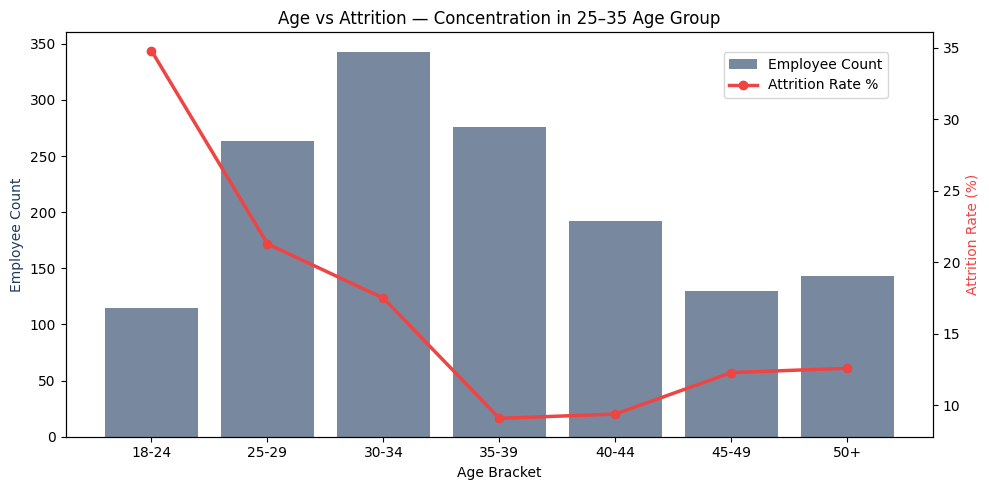

In [13]:
# DEMOGRAPHIC DISTRIBUTIONS
# For Dataset Page — Age, Role, Department

# Age vs Attrition
df_raw["AgeBracket"] = pd.cut(
    df_raw["Age"],
    bins=[18, 25, 30, 35, 40, 45, 50, 65],
    labels=["18-24","25-29","30-34","35-39","40-44","45-49","50+"]
)
age_attr = df_raw.groupby("AgeBracket", observed=True)["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1)
age_count = df_raw.groupby("AgeBracket", observed=True).size()

print("\nAttrition Rate by Age Bracket:")
print(age_attr)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
bars = ax1.bar(age_attr.index.astype(str), age_count.values,
               color="#1e3a5f", alpha=0.6, label="Employee Count")
line = ax2.plot(age_attr.index.astype(str), age_attr.values,
                color="#ef4444", marker="o", linewidth=2.5,
                label="Attrition Rate %")
ax1.set_xlabel("Age Bracket")
ax1.set_ylabel("Employee Count", color="#1e3a5f")
ax2.set_ylabel("Attrition Rate (%)", color="#ef4444")
ax1.set_title("Age vs Attrition — Concentration in 25–35 Age Group")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.savefig("age_vs_attrition.png", dpi=150, bbox_inches="tight")
plt.show()


Attrition Rate by Job Role:
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: Attrition, dtype: float64


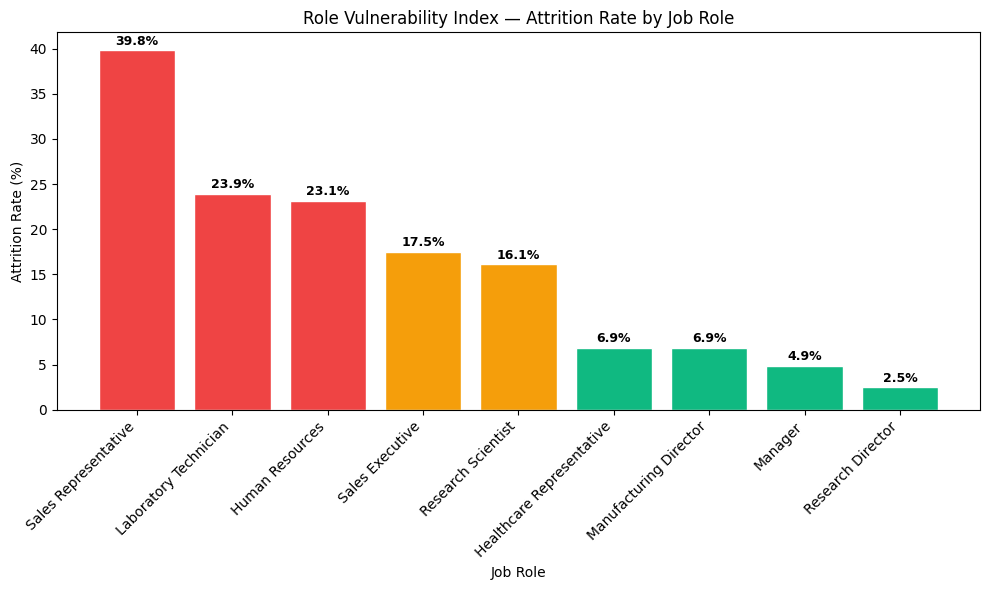

In [14]:
# Role Vulnerability Index

role_attr = df_raw.groupby("JobRole")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1).sort_values(ascending=False)
role_count = df_raw.groupby("JobRole").size()

print("\nAttrition Rate by Job Role:")
print(role_attr)

colors_role = ["#ef4444" if v > 20 else "#f59e0b" if v > 10 else "#10b981"
               for v in role_attr.values]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(role_attr.index, role_attr.values, color=colors_role, edgecolor="white")
for bar, val in zip(bars, role_attr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Role Vulnerability Index — Attrition Rate by Job Role")
ax.set_ylabel("Attrition Rate (%)")
ax.set_xlabel("Job Role")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("role_vulnerability.png", dpi=150, bbox_inches="tight")
plt.show()


Attrition Rate by Department:
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition, dtype: float64


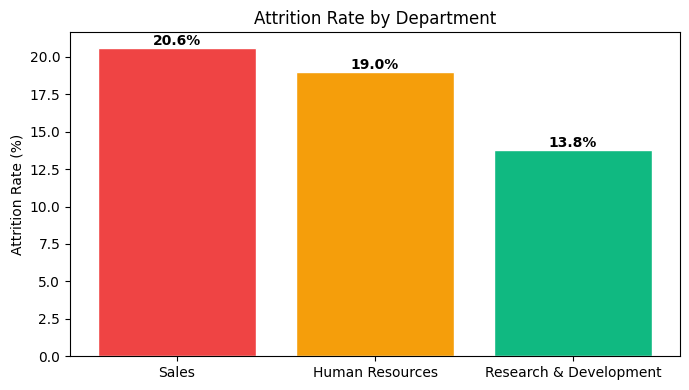

In [15]:
# Department Attrition

dept_attr = df_raw.groupby("Department")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1).sort_values(ascending=False)

print("\nAttrition Rate by Department:")
print(dept_attr)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dept_attr.index, dept_attr.values,
              color=["#ef4444","#f59e0b","#10b981"][:len(dept_attr)],
              edgecolor="white")
for bar, val in zip(bars, dept_attr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{val}%", ha="center", fontweight="bold")
ax.set_title("Attrition Rate by Department")
ax.set_ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.savefig("dept_attrition.png", dpi=150, bbox_inches="tight")
plt.show()



Attrition Rate by Overtime:
OverTime
No     10.4
Yes    30.5
Name: Attrition, dtype: float64


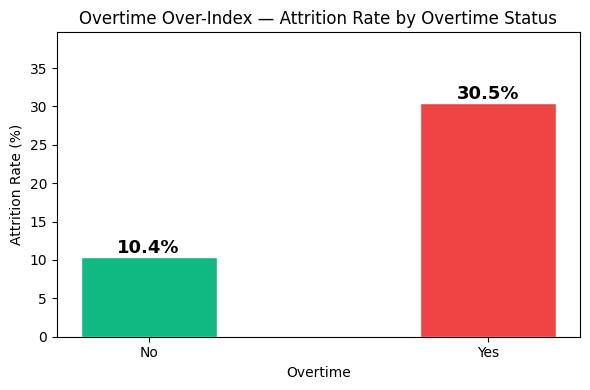

In [16]:
# KEY DRIVING SIGNALS
# For Dataset Page — Driving Signals Grid

# Overtime vs Attrition
ot_attr = df_raw.groupby("OverTime")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1)

print("\nAttrition Rate by Overtime:")
print(ot_attr)

fig, ax = plt.subplots(figsize=(6, 4))
colors_ot = ["#10b981", "#ef4444"]
bars = ax.bar(ot_attr.index, ot_attr.values, color=colors_ot,
              edgecolor="white", width=0.4)
for bar, val in zip(bars, ot_attr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val}%", ha="center", fontsize=13, fontweight="bold")
ax.set_title("Overtime Over-Index — Attrition Rate by Overtime Status")
ax.set_ylabel("Attrition Rate (%)")
ax.set_xlabel("Overtime")
ax.set_ylim(0, max(ot_attr.values) * 1.3)
plt.tight_layout()
plt.savefig("overtime_attrition.png", dpi=150, bbox_inches="tight")
plt.show()


Mean Income — Stayed: $6833
Mean Income — Left:   $4787


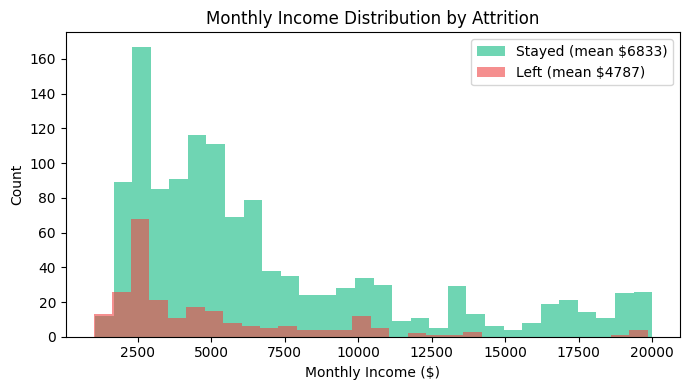

In [17]:
# Income vs Attrition

stayed = df_raw[df_raw["Attrition"] == "No"]["MonthlyIncome"]
left   = df_raw[df_raw["Attrition"] == "Yes"]["MonthlyIncome"]

print(f"\nMean Income — Stayed: ${stayed.mean():.0f}")
print(f"Mean Income — Left:   ${left.mean():.0f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(stayed, bins=30, alpha=0.6, color="#10b981", label=f"Stayed (mean ${stayed.mean():.0f})")
ax.hist(left,   bins=30, alpha=0.6, color="#ef4444", label=f"Left (mean ${left.mean():.0f})")
ax.set_title("Monthly Income Distribution by Attrition")
ax.set_xlabel("Monthly Income ($)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("income_attrition.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# Business Travel vs Attrition

travel_attr = df_raw.groupby("BusinessTravel")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1)
print("\nAttrition Rate by Business Travel:")
print(travel_attr)


Attrition Rate by Business Travel:
BusinessTravel
Non-Travel            8.0
Travel_Frequently    24.9
Travel_Rarely        15.0
Name: Attrition, dtype: float64


In [19]:
# Marital Status vs Attrition

marital_attr = df_raw.groupby("MaritalStatus")["Attrition"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).round(1)
print("\nAttrition Rate by Marital Status:")
print(marital_attr)


Attrition Rate by Marital Status:
MaritalStatus
Divorced    10.1
Married     12.5
Single      25.5
Name: Attrition, dtype: float64


In [20]:
# Dataset Profile Summary Table

numeric_cols = X.select_dtypes(include=[np.number]).columns
profile_data = []
for col in numeric_cols[:20]:
    profile_data.append({
        "Feature": col,
        "Type": "Numeric (Scaled)",
        "Min": round(float(X[col].min()), 3),
        "Max": round(float(X[col].max()), 3),
        "Mean": round(float(X[col].mean()), 3),
        "Std": round(float(X[col].std()), 3),
    })

profile_df = pd.DataFrame(profile_data)
print(profile_df.to_string(index=False))
profile_df.to_csv("dataset_profile.csv", index=False)
print("\ndataset_profile.csv saved")

                 Feature             Type    Min   Max  Mean  Std
                     Age Numeric (Scaled) -2.072 2.527  -0.0  1.0
               DailyRate Numeric (Scaled) -1.737 1.727   0.0  1.0
        DistanceFromHome Numeric (Scaled) -1.011 2.444   0.0  1.0
               Education Numeric (Scaled) -1.868 2.039  -0.0  1.0
 EnvironmentSatisfaction Numeric (Scaled) -1.576 1.170   0.0  1.0
              HourlyRate Numeric (Scaled) -1.766 1.678   0.0  1.0
          JobInvolvement Numeric (Scaled) -2.432 1.786   0.0  1.0
                JobLevel Numeric (Scaled) -0.961 2.653  -0.0  1.0
         JobSatisfaction Numeric (Scaled) -1.568 1.153   0.0  1.0
           MonthlyIncome Numeric (Scaled) -1.167 2.868  -0.0  1.0
             MonthlyRate Numeric (Scaled) -1.717 1.783   0.0  1.0
      NumCompaniesWorked Numeric (Scaled) -1.079 2.526   0.0  1.0
       PercentSalaryHike Numeric (Scaled) -1.151 2.676   0.0  1.0
       PerformanceRating Numeric (Scaled) -0.426 2.346  -0.0  1.0
Relationsh

In [24]:
# FEATURE IMPORTANCE ACROSS MODELS
# For Dataset Page + Performance Page

# XGBoost importance
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance_XGB": xgb_model.feature_importances_
}).sort_values("Importance_XGB", ascending=False)

print("\nTop 15 XGBoost Features:")
print(xgb_importance.head(15).to_string(index=False))


Top 15 XGBoost Features:
                       Feature  Importance_XGB
                  OverTime_Yes        0.189853
              StockOptionLevel        0.070590
     JobRole_Research Director        0.060200
                      JobLevel        0.053817
             PerformanceRating        0.045250
                 WorkloadScore        0.041145
       JobRole_Sales Executive        0.038301
          MaritalStatus_Single        0.035071
JobRole_Manufacturing Director        0.026742
                JobInvolvement        0.024895
               JobSatisfaction        0.024317
               WorkLifeBalance        0.020466
    JobRole_Research Scientist        0.019383
            YearsInCurrentRole        0.017495
                   Gender_Male        0.017069


In [25]:
# Random Forest importance

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance_RF": rf_model.feature_importances_
}).sort_values("Importance_RF", ascending=False)

print("\nTop 15 Random Forest Features:")
print(rf_importance.head(15).to_string(index=False))


Top 15 Random Forest Features:
                Feature  Importance_RF
           OverTime_Yes       0.082003
          WorkloadScore       0.081191
       StockOptionLevel       0.056219
        JobSatisfaction       0.049692
   MaritalStatus_Single       0.045456
EnvironmentSatisfaction       0.031735
                    Age       0.030907
               JobLevel       0.030750
          MonthlyIncome       0.030482
      TotalWorkingYears       0.030090
          IncomePerYear       0.028121
           SalaryGrowth       0.025922
         YearsAtCompany       0.025173
         JobInvolvement       0.023780
       DistanceFromHome       0.023388


In [26]:
# Logistic Regression coefficients

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0],
    "Absolute": abs(log_model.coef_[0])
}).sort_values("Absolute", ascending=False)

print("\nTop 15 Logistic Regression Coefficients:")
print(coef_df.head(15).to_string(index=False))


Top 15 Logistic Regression Coefficients:
                          Feature  Coefficient  Absolute
                    WorkloadScore     0.745028  0.745028
Department_Research & Development     0.740279  0.740279
          JobRole_Sales Executive     0.726710  0.726710
             MaritalStatus_Single     0.699487  0.699487
     JobRole_Sales Representative     0.608286  0.608286
                TotalWorkingYears    -0.592602  0.592602
                   YearsAtCompany     0.571694  0.571694
          EnvironmentSatisfaction    -0.509910  0.509910
     BusinessTravel_Travel_Rarely     0.501027  0.501027
               NumCompaniesWorked     0.497305  0.497305
    JobRole_Laboratory Technician     0.491316  0.491316
          JobRole_Human Resources     0.482200  0.482200
          YearsSinceLastPromotion     0.481274  0.481274
        JobRole_Research Director    -0.455925  0.455925
                     SalaryGrowth     0.422923  0.422923


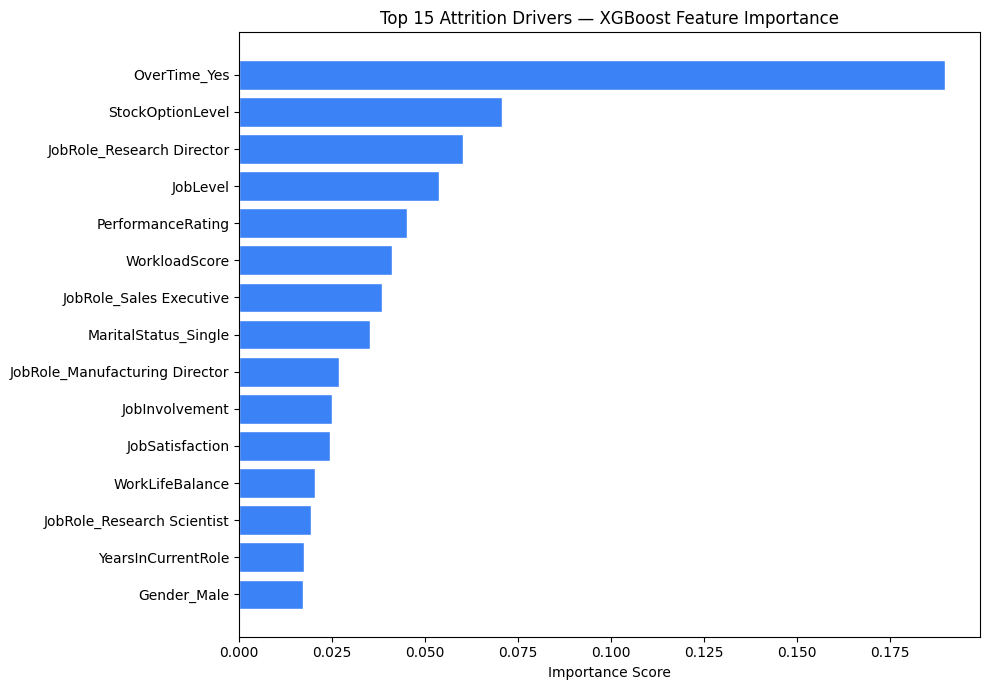

In [27]:
# XGBoost importance chart

fig, ax = plt.subplots(figsize=(10, 7))
top15 = xgb_importance.head(15)
bars = ax.barh(top15["Feature"][::-1], top15["Importance_XGB"][::-1],
               color="#3b82f6", edgecolor="white")
ax.set_title("Top 15 Attrition Drivers — XGBoost Feature Importance")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# BATCH ANALYSIS SIMULATION
# Numbers the Batch Analysis page will show

THRESHOLD = 0.3

# Predict on full dataset
probs_xgb = xgb_model.predict_proba(X)[:, 1]
probs_rf   = rf_model.predict_proba(X)[:, 1]
probs_lr   = log_model.predict_proba(X)[:, 1]

preds_xgb = (probs_xgb >= THRESHOLD).astype(int)
preds_rf   = (probs_rf  >= THRESHOLD).astype(int)
preds_lr   = (probs_lr  >= THRESHOLD).astype(int)

In [29]:
# Risk tier counts

def get_risk_counts(probs, threshold=0.3):
    high   = (probs >= 0.6).sum()
    medium = ((probs >= threshold) & (probs < 0.6)).sum()
    low    = (probs < threshold).sum()
    return {"High Risk": int(high), "Moderate Risk": int(medium), "Low Risk": int(low)}

xgb_risk = get_risk_counts(probs_xgb)
rf_risk   = get_risk_counts(probs_rf)
lr_risk   = get_risk_counts(probs_lr)

print("\nXGBoost Risk Tiers:")
print(xgb_risk)
print("\nRandom Forest Risk Tiers:")
print(rf_risk)
print("\nLogistic Regression Risk Tiers:")
print(lr_risk)


XGBoost Risk Tiers:
{'High Risk': 237, 'Moderate Risk': 0, 'Low Risk': 1233}

Random Forest Risk Tiers:
{'High Risk': 237, 'Moderate Risk': 3, 'Low Risk': 1230}

Logistic Regression Risk Tiers:
{'High Risk': 339, 'Moderate Risk': 331, 'Low Risk': 800}


In [30]:
# Avg probability

print(f"\nXGBoost   Avg Attrition Prob: {probs_xgb.mean()*100:.1f}%")
print(f"RF        Avg Attrition Prob: {probs_rf.mean()*100:.1f}%")
print(f"LR        Avg Attrition Prob: {probs_lr.mean()*100:.1f}%")


XGBoost   Avg Attrition Prob: 16.3%
RF        Avg Attrition Prob: 19.4%
LR        Avg Attrition Prob: 33.9%


In [31]:
# Financial liability

avg_income    = df_raw["MonthlyIncome"].mean() if "MonthlyIncome" in df_raw.columns else 6500
replacement   = avg_income * 6
high_risk_n   = xgb_risk["High Risk"]
total_liability = round(high_risk_n * replacement)
print(f"\nEstimated Replacement Cost per Employee: ${replacement:,.0f}")
print(f"High Risk Employees (XGB): {high_risk_n}")
print(f"Total Financial Liability: ${total_liability:,}")


Estimated Replacement Cost per Employee: $39,018
High Risk Employees (XGB): 237
Total Financial Liability: $9,247,168


In [32]:
# Workforce health index

health_score = round(100 - (xgb_risk["High Risk"] / len(df_raw) * 100), 1)
print(f"\nWorkforce Health Index: {health_score}/100")


Workforce Health Index: 83.9/100



Department Risk Breakdown:
RiskTier                Low Risk  High Risk
Department                                 
Human Resources               51         12
Research & Development       828        133
Sales                        354         92


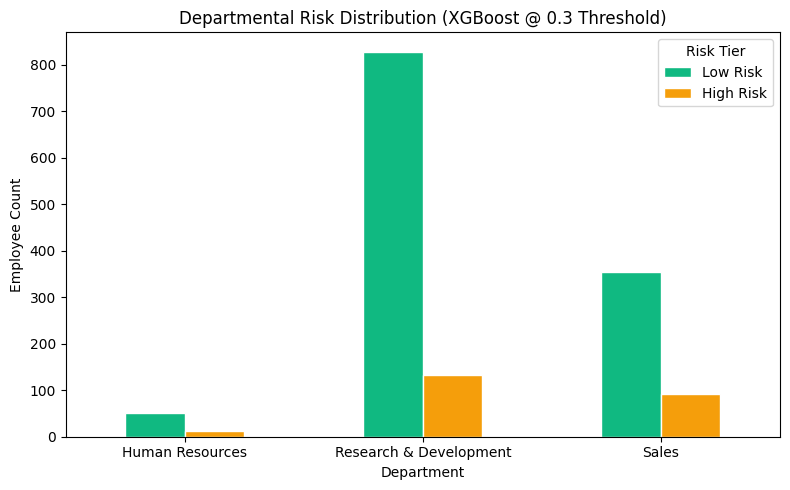

In [33]:
# Department risk breakdown using raw data

if "Department" in df_raw.columns:
    df_raw["AttritionProb_XGB"] = probs_xgb
    df_raw["RiskTier"] = pd.cut(
        probs_xgb,
        bins=[0, 0.3, 0.6, 1.0],
        labels=["Low Risk", "Moderate Risk", "High Risk"]
    )
    dept_risk = df_raw.groupby(["Department","RiskTier"], observed=True).size().unstack(fill_value=0)
    print("\nDepartment Risk Breakdown:")
    print(dept_risk)

    fig, ax = plt.subplots(figsize=(8, 5))
    dept_risk.plot(kind="bar", ax=ax,
                   color=["#10b981","#f59e0b","#ef4444"],
                   edgecolor="white")
    ax.set_title("Departmental Risk Distribution (XGBoost @ 0.3 Threshold)")
    ax.set_xlabel("Department")
    ax.set_ylabel("Employee Count")
    ax.legend(title="Risk Tier")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig("dept_risk_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


Job Role Risk Breakdown:
RiskTier                   Low Risk  High Risk  HighRiskTotal
JobRole                                                      
Laboratory Technician           197         62             62
Sales Executive                 269         57             57
Research Scientist              245         47             47
Sales Representative             50         33             33
Human Resources                  40         12             12
Manufacturing Director          135         10             10
Healthcare Representative       122          9              9
Manager                          97          5              5
Research Director                78          2              2


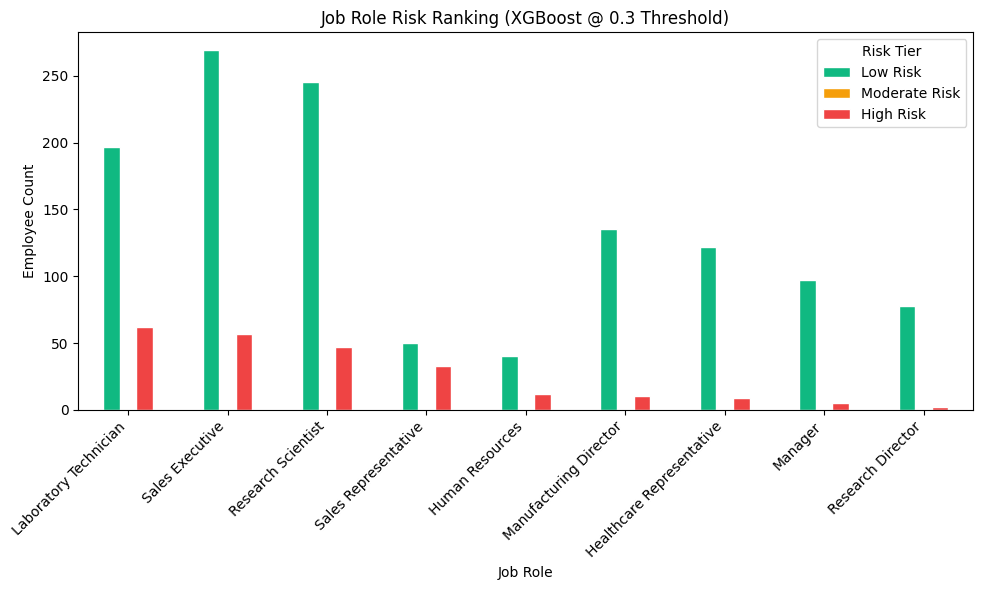

In [39]:
# Job Role risk breakdown

if "JobRole" in df_raw.columns:
    role_risk = df_raw.groupby(["JobRole","RiskTier"], observed=True).size().unstack(fill_value=0)
    role_risk["HighRiskTotal"] = role_risk.get("High Risk", 0)
    role_risk = role_risk.sort_values("HighRiskTotal", ascending=False)
    print("\nJob Role Risk Breakdown:")
    print(role_risk)

    # Force all 3 risk tier columns to exist even if empty
role_risk = role_risk.reindex(
    columns=["Low Risk", "Moderate Risk", "High Risk"],
    fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 6))
role_risk[["Low Risk", "Moderate Risk", "High Risk"]].plot(
    kind="bar", ax=ax,
    color=["#10b981", "#f59e0b", "#ef4444"],
    edgecolor="white"
)
ax.set_title("Job Role Risk Ranking (XGBoost @ 0.3 Threshold)")
ax.set_xlabel("Job Role")
ax.set_ylabel("Employee Count")
ax.legend(title="Risk Tier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("role_risk_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
# MODEL BENCHMARKING
# For Batch Analysis — Model Evaluation Grid

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

benchmarks = []
for name, probs in [("XGBoost", probs_xgb), ("Random Forest", probs_rf),
                     ("Logistic Regression", probs_lr)]:
    preds = (probs >= THRESHOLD).astype(int)
    tp = int(((preds == 1) & (y == 1)).sum())
    tn = int(((preds == 0) & (y == 0)).sum())
    fp = int(((preds == 1) & (y == 0)).sum())
    fn = int(((preds == 0) & (y == 1)).sum())
    acc = round(accuracy_score(y, preds) * 100, 1)
    rec = round(recall_score(y, preds) * 100, 1)
    prec = round(precision_score(y, preds) * 100, 1)
    f1  = round(f1_score(y, preds) * 100, 1)
    benchmarks.append({
        "Model": name,
        "Correctly Identified": tp + tn,
        "Wrongly Identified": fp,
        "Missed Records (FN)": fn,
        "Accuracy (%)": acc,
        "Recall (%)": rec,
        "Precision (%)": prec,
        "F1 Score (%)": f1,
    })

bench_df = pd.DataFrame(benchmarks)
print("\nModel Benchmarking Grid:")
print(bench_df.to_string(index=False))
bench_df.to_csv("model_benchmarks.csv", index=False)


Model Benchmarking Grid:
              Model  Correctly Identified  Wrongly Identified  Missed Records (FN)  Accuracy (%)  Recall (%)  Precision (%)  F1 Score (%)
            XGBoost                  1470                   0                    0         100.0       100.0          100.0         100.0
      Random Forest                  1467                   3                    0          99.8       100.0           98.8          99.4
Logistic Regression                   985                 459                   26          67.0        89.0           31.5          46.5


In [41]:
# CRITICAL SIGNALS FOR BATCH PAGE

if "OverTime" in df_raw.columns:
    high_risk_mask = probs_xgb >= 0.6
    high_risk_df   = df_raw[high_risk_mask]
    ot_pct = round((high_risk_df["OverTime"] == "Yes").sum() / len(high_risk_df) * 100, 1)
    print(f"% of High-Risk employees on Overtime: {ot_pct}%")
    print(f"→ System Flag: {ot_pct}% of high-risk employees are on mandatory overtime")

if "BusinessTravel" in df_raw.columns:
    travel_pct = round(
        (high_risk_df["BusinessTravel"] == "Travel_Frequently").sum() / len(high_risk_df) * 100, 1
    )
    print(f"% of High-Risk employees with Frequent Travel: {travel_pct}%")

if "MonthlyIncome" in df_raw.columns:
    avg_high_income = high_risk_df["MonthlyIncome"].mean()
    avg_low_income  = df_raw[probs_xgb < 0.3]["MonthlyIncome"].mean()
    print(f"Avg Income — High Risk:  ${avg_high_income:,.0f}")
    print(f"Avg Income — Low Risk:   ${avg_low_income:,.0f}")
    print(f"Income gap: ${avg_low_income - avg_high_income:,.0f} higher for low-risk employees")

% of High-Risk employees on Overtime: 53.6%
→ System Flag: 53.6% of high-risk employees are on mandatory overtime
% of High-Risk employees with Frequent Travel: 29.1%
Avg Income — High Risk:  $4,787
Avg Income — Low Risk:   $6,833
Income gap: $2,046 higher for low-risk employees


In [45]:
# SAVE ALL OUTPUTS

importance_df = xgb_importance.merge(rf_importance, on="Feature")
importance_df.to_csv("attrition_driver_analysis.csv", index=False)
print("attrition_drivers_analysis.csv saved")
bench_df.to_csv("model_benchmarks.csv", index=False)
print("model_benchmarks.csv saved")

attrition_drivers_analysis.csv saved
model_benchmarks.csv saved


In [47]:
# Download

files.download("attrition_drivers_analysis.csv")
files.download("model_benchmarks.csv")
files.download("dataset_profile.csv")

print("Key numbers for the website:")
print(f"  Total Records      : {len(df_raw)}")
print(f"  Attrition Rate     : {attrition_rate}%")
print(f"  Health Index       : {health_score}/100")
print(f"  Financial Liability: ${total_liability:,}")
print(f"  High Risk Count    : {high_risk_n}")
print(f"  XGB Risk Tiers     : {xgb_risk}")
print(f"  Overtime in HighRisk: {ot_pct}%")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Key numbers for the website:
  Total Records      : 1470
  Attrition Rate     : 16.1%
  Health Index       : 83.9/100
  Financial Liability: $9,247,168
  High Risk Count    : 237
  XGB Risk Tiers     : {'High Risk': 237, 'Moderate Risk': 0, 'Low Risk': 1233}
  Overtime in HighRisk: 53.6%
